# Домашнее задание 7
## Полушина Дарья Б06-303
## Отчет

### Часть 1 — Анализ дифференциальной экспрессии (DESeq2)

В этой части будет проанализирована дифференциальная экспрессия между ответчиками и неответчиками на терапию иммун-чекпоинтных ингибиторов при раке легкого. 

**Цель исследования:** выявить гены, дифференциально экспрессированные между пациентами с раком легкого, которые ответили (R) и не ответили (NR) на терапию ингибиторами иммунных чекпоинтов.

**Данные:** RNA-seq counts (количественная оценка экспрессии генов).

**Метод:** DESeq2 — предназначен для анализа RNA-seq на основе отрицательного биномиального распределения, учитывает дисперсию между биологическими повторами.

**Конечная цель:** Найти потенциальные биомаркеры ответа на иммунотерапию.

Для начала сделаем PCA и посмотрим, как сгруппировались гены.

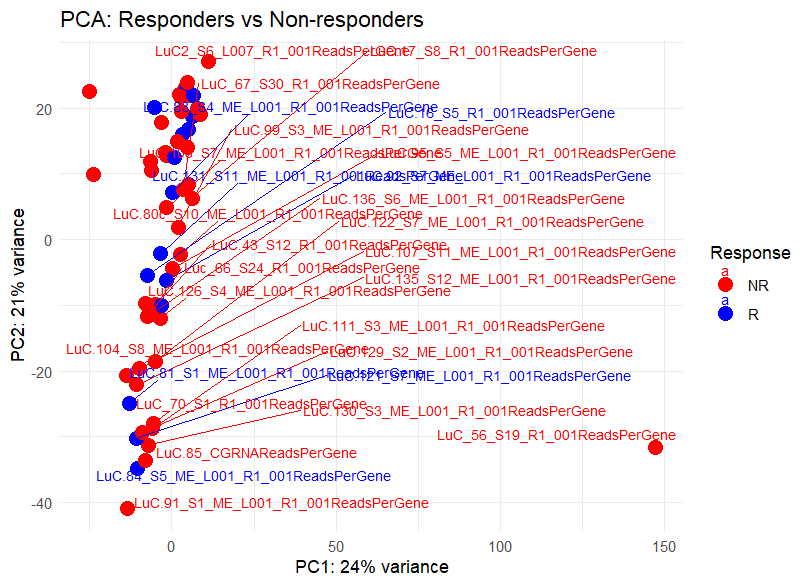

На PCA заметно, что образец LuC_56_S19_R1_001ReadsPerGene из группы NR находится на значительном удалении от других NR. Исключим его для дальнейшего анализа.

Далее строим тепловую карту образцов.

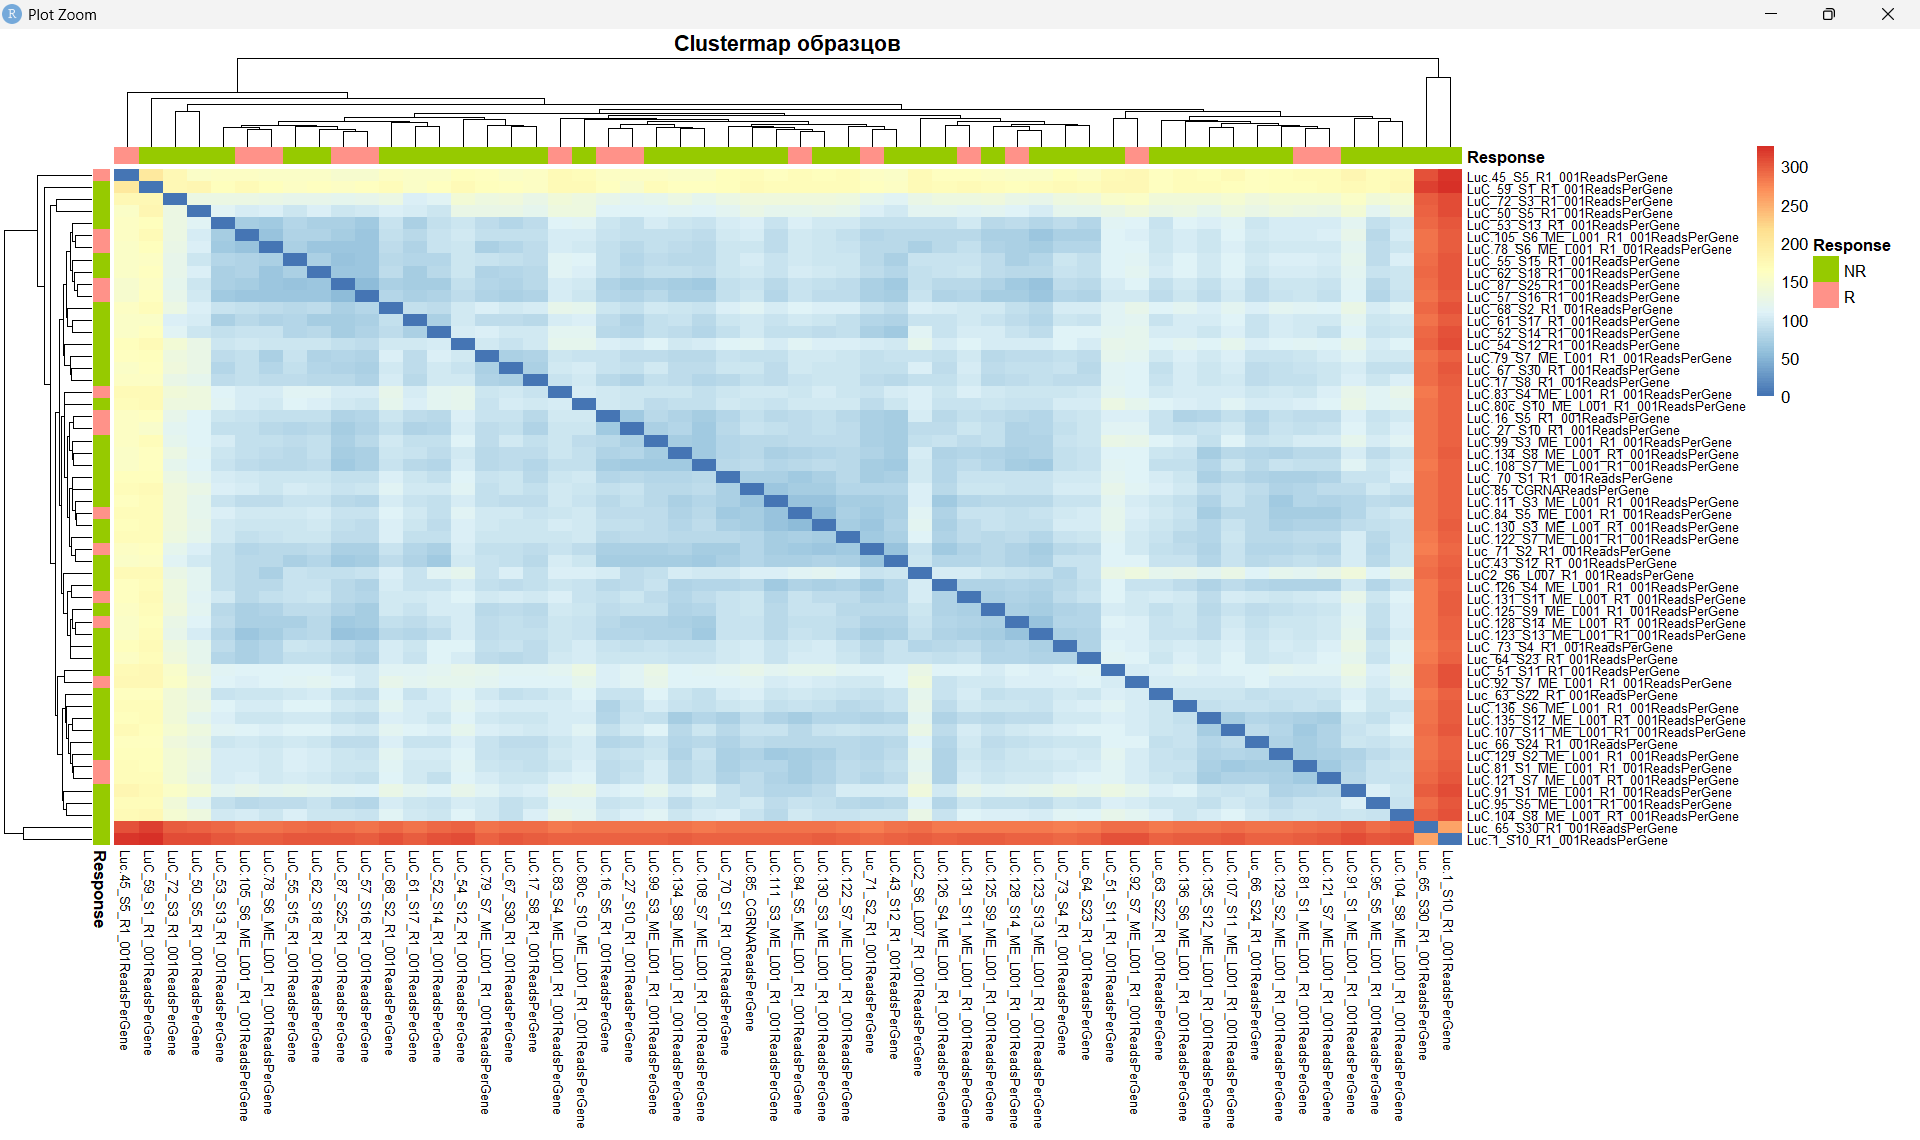

На тепловой карте представлены евклидовы расстояния между образцами (то есть их сходство) в пространстве экспрессии всех генов (после VST-преобразования). Значения варьируют от 0 (полное сходство, темно-синий цвет) до 300 (максимальное различие, красный цвет).

Ключевые наблюдения:
- диагональ имеет значение 0 (образец идентичен себе), что подтверждает корректность расчетов
- основная масса образцов имеет сходство друг с другом (большая часть карты бело-голубая и желтоватая, что указывает на среднюю степень сходства)
- два образца (Luc.1_S10_R1_001ReadsPerGene, Luc_65_S30_R1_001ReadsPerGene) дают полностью красные строки и столбцы, помимо этого есть желтые строки и столбцы
- значит, есть четкое разделение на группы, внутри которых образцы очень схожи друг с другом

Теперь переходим к выявлению дифференциально экспрессированных генов. Для этого была получена таблица res с p value и fold change, далее построен volcano plot для результатов дифференциальной экспрессии.

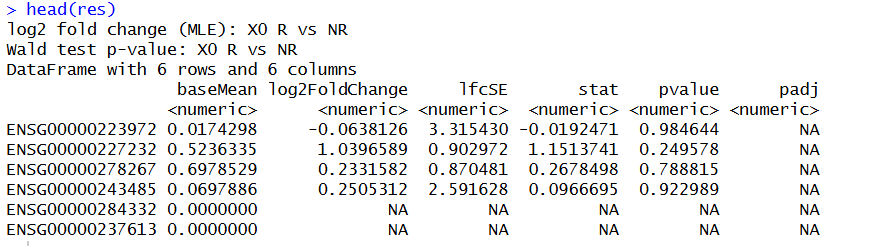

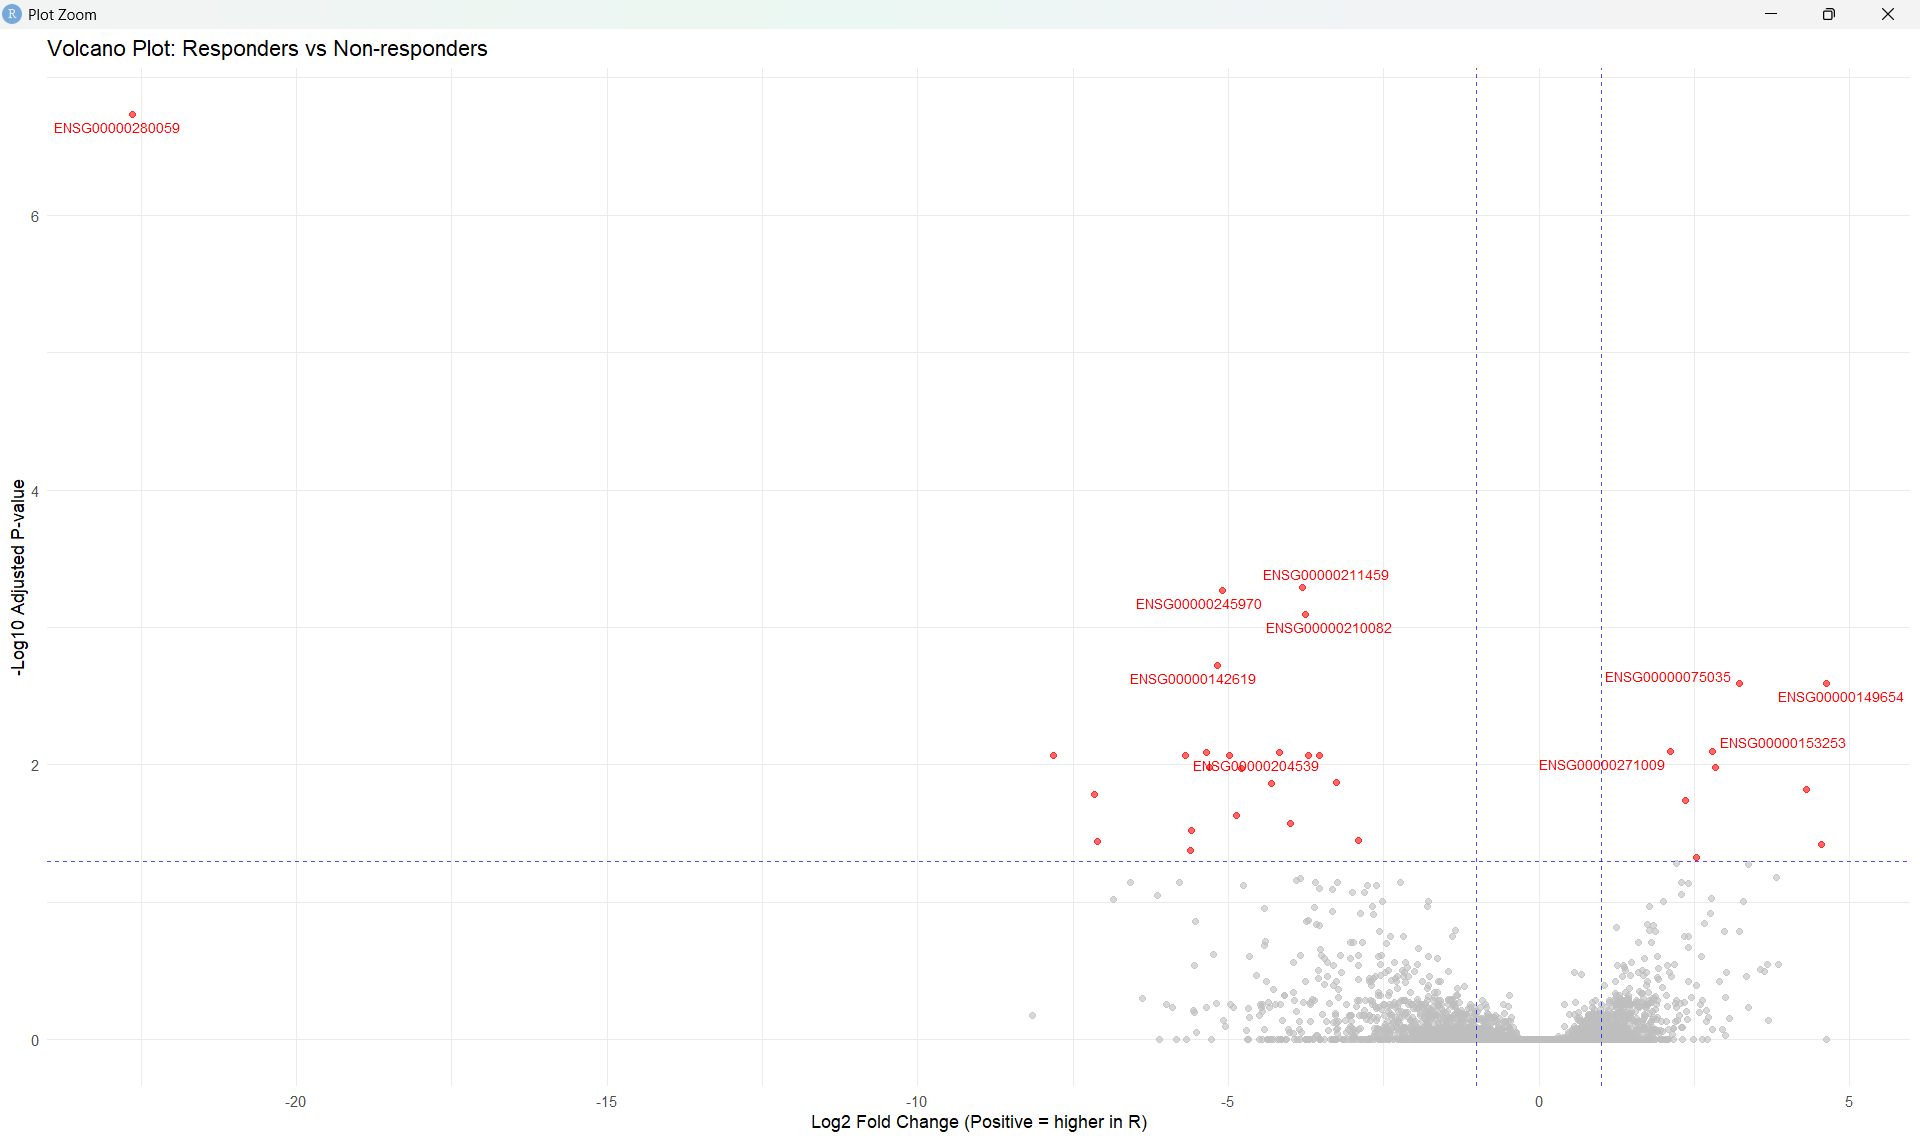

Я получила volcano plot, где есть серые точки — незначимые гены (около 0), красные точки — значимые гены (выше и по бокам от 0), синие линии — пороги (|log2FC| = 1 и padj = 0.05). Есть очень сильно дифференциально экспрессированный ген - самая далекая красная точка. Этот ген очень сильно меняется (большой log2FoldChange, ось X), что статистически очень значимо (высоко по Y, то есть очень маленький p-value). Значит, найден биологически значимый ген, который очень сильно отличается между R и NR. Данные работают — DESeq2 смог обнаружить сильное различие.

#### Выводы:

В данной части задания был проведен анализ дифференциальной экспрессии генов (RNA-seq) для образцов рака легкого (LuC) с целью выявления транскрипционных различий между пациентами, ответившими (R) и не ответившими (NR) на терапию ингибиторами иммунных чекпоинтов. Для этого был проведен PCA анализ, который помог выявить выброс. После удаления выброса проводился дальнейший анализ по тепловой карте, были выявлены раздельные кластеры образцов, что показывает возможность использовать данные для анализа дифференциальной экспрессии. Анализ диф. экспрессии смог выявить дифференциально экспессированные гены и найти один важный ген, который и может играть ключевую роль в ответе на иммунотерапию. Цель была выполнена.

### Часть 2 —Анализ дифференциальной экспрессии (LIMMA)

**Цель:** провести анализ дифференциальной экспрессии генов между пациентами с полным ответом (pCR) и неполным ответом (pNC) с использованием пакета LIMMA.

**Данные:** Микрочипы GSE63885. Данные загружены из файлов:
- `expression_for_limma2.csv` — матрица экспрессии (гены в строках, образцы в колонках)
- `annotation_for_limma.csv` — метаданные образцов (клинический статус ответа на терапию)

Пакет LIMMA был разработан специально для анализа микрочиповых данных, где значения экспрессии имеют непрерывную природу . В отличие от DESeq2 (предназначенного для целочисленных RNA-seq counts), LIMMA использует линейные модели с эмпирическим байесовским сжатием дисперсии, что позволяет эффективно обрабатывать данные с небольшим количеством повторов и оценивать изменения сразу в целых группах экспериментов. 

Для анализа запускаем скрипт LIMMA, который загружает и обрабатывает данные, создает дизайн-матрицу и после байесовского сжатия диспрерсии выдает таблицу результатов (таблицу дифференциально экспрессированных генов с коэффициентом pCR). Для оценки влияния порога LogFC были добавлены три столбца, указывающие на значимость гена при порогах |logFC| > 1, |logFC| > 2 и |logFC| > 3 (при adj.P.Val < 0.05).

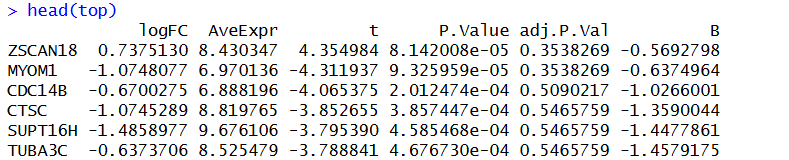

В данной таблице для каждого гена приведены следующие параметры: логарифмическое изменение экспрессии (pCR vs pNC), средняя экспрессия гена, t-статистика, p-value, скорректированное после байесовского сжатия дисперсии p-value и логарифм отношения шансов.

Результаты:
- |logFC| > 1, adj.P.Val < 0.05 - 0 значимых генов
- |logFC| > 2, adj.P.Val < 0.05	- 0 значимых генов
- |logFC| > 3, adj.P.Val < 0.05	- 0 значимых генов

При всех трех порогах (1, 2, 3) не было выявлено ни одного гена, удовлетворяющего критерию adj.P.Val < 0.05. Это означает, что после поправки на множественные сравнения ни один ген не демонстрирует статистически значимых различий между группами pCR и pNC.

При этом анализ p-value показал, что аспределение p-value близко к равномерному с небольшим подъемом в области малых значений

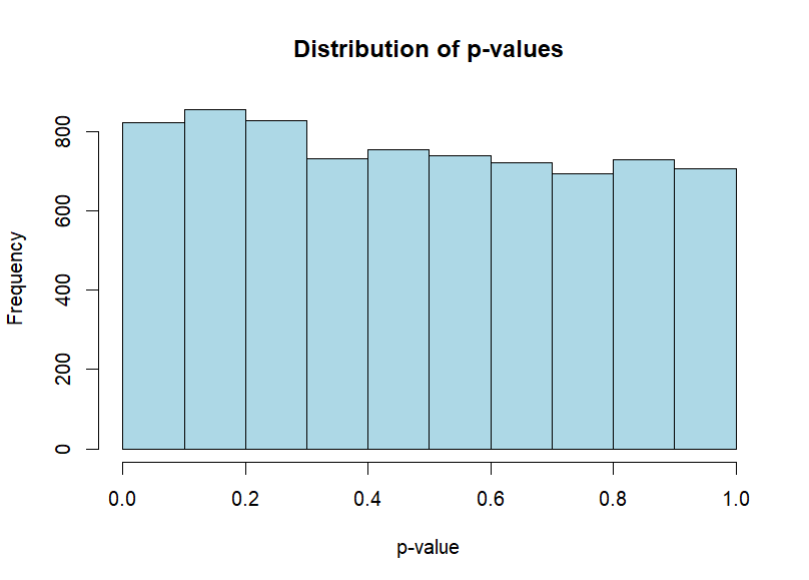

Для каждого порога LogFC (1, 2, 3) построен вулкан-график, на котором по оси X отложен logFC, а по оси Y — -log10(adj.P.Val).

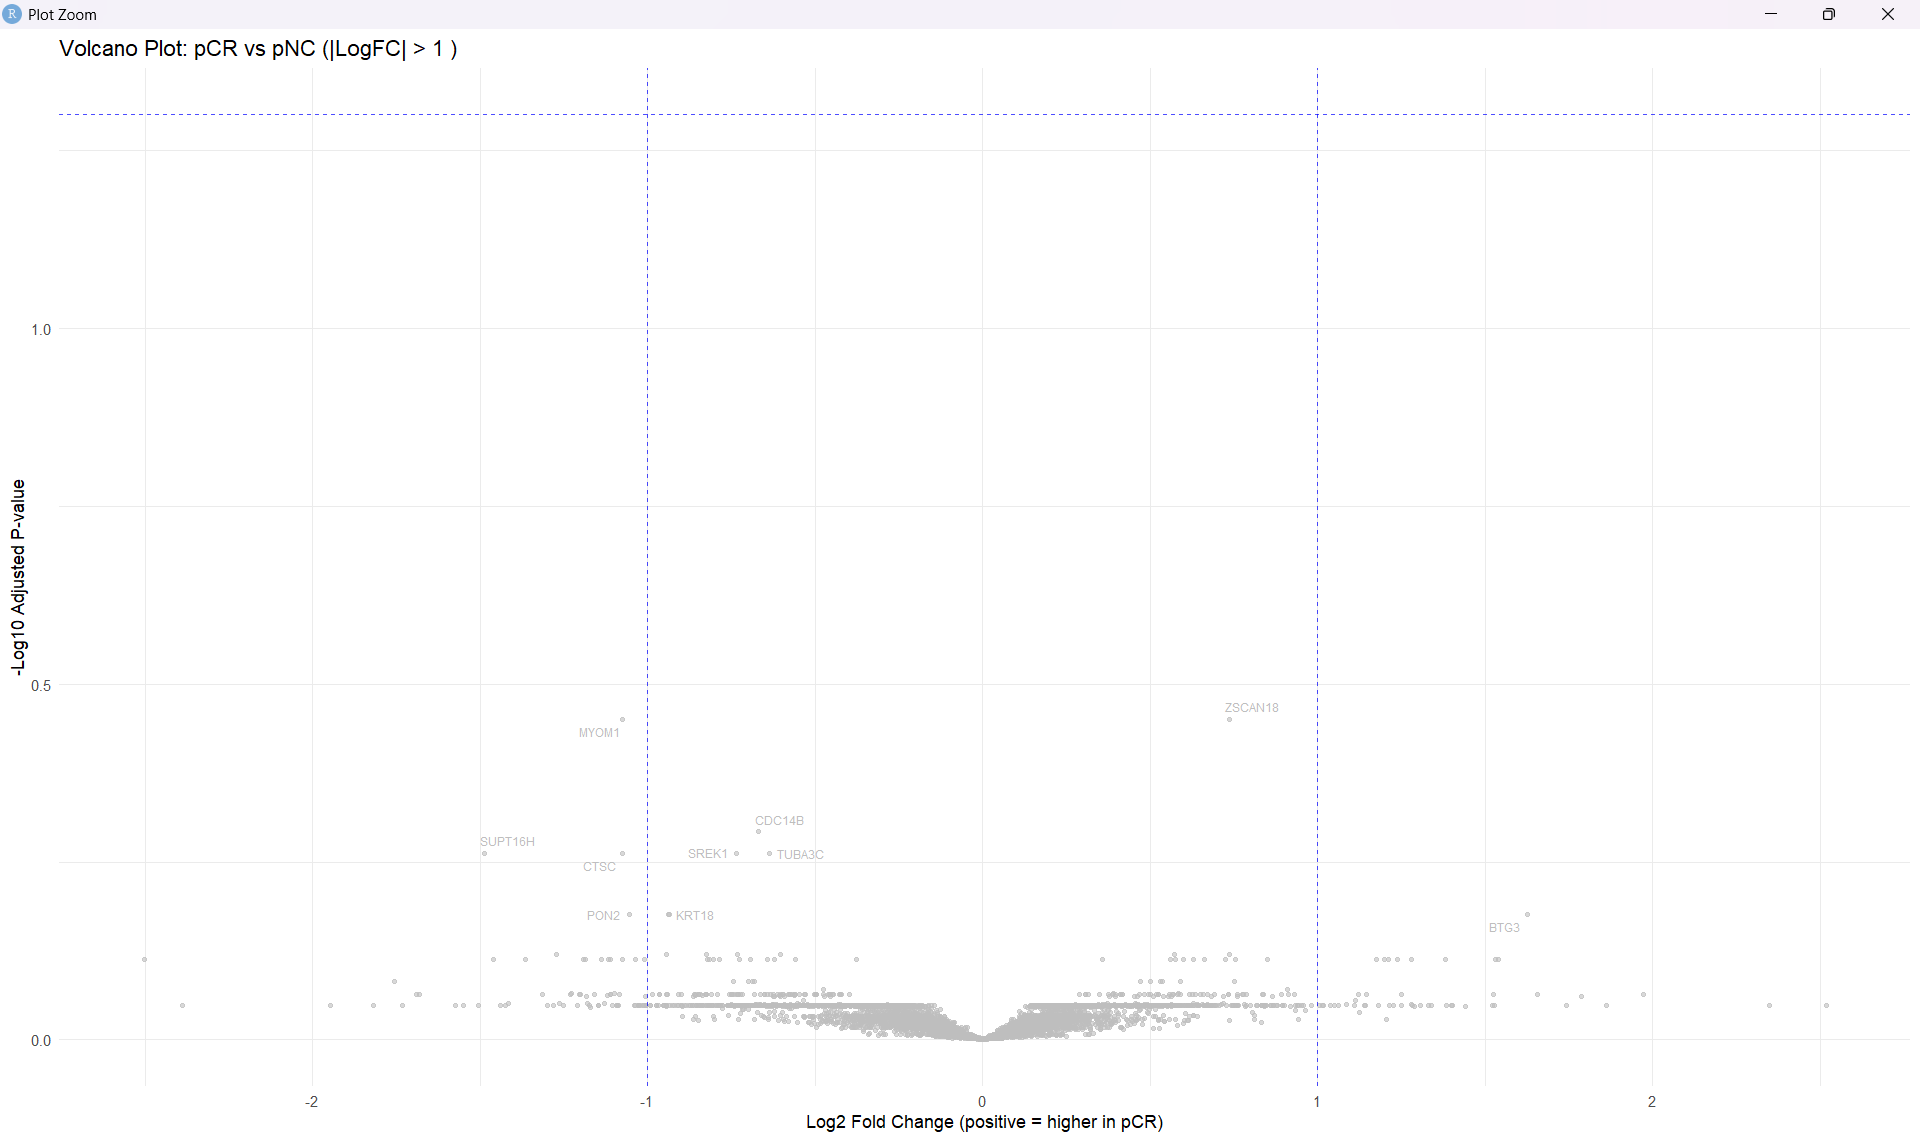

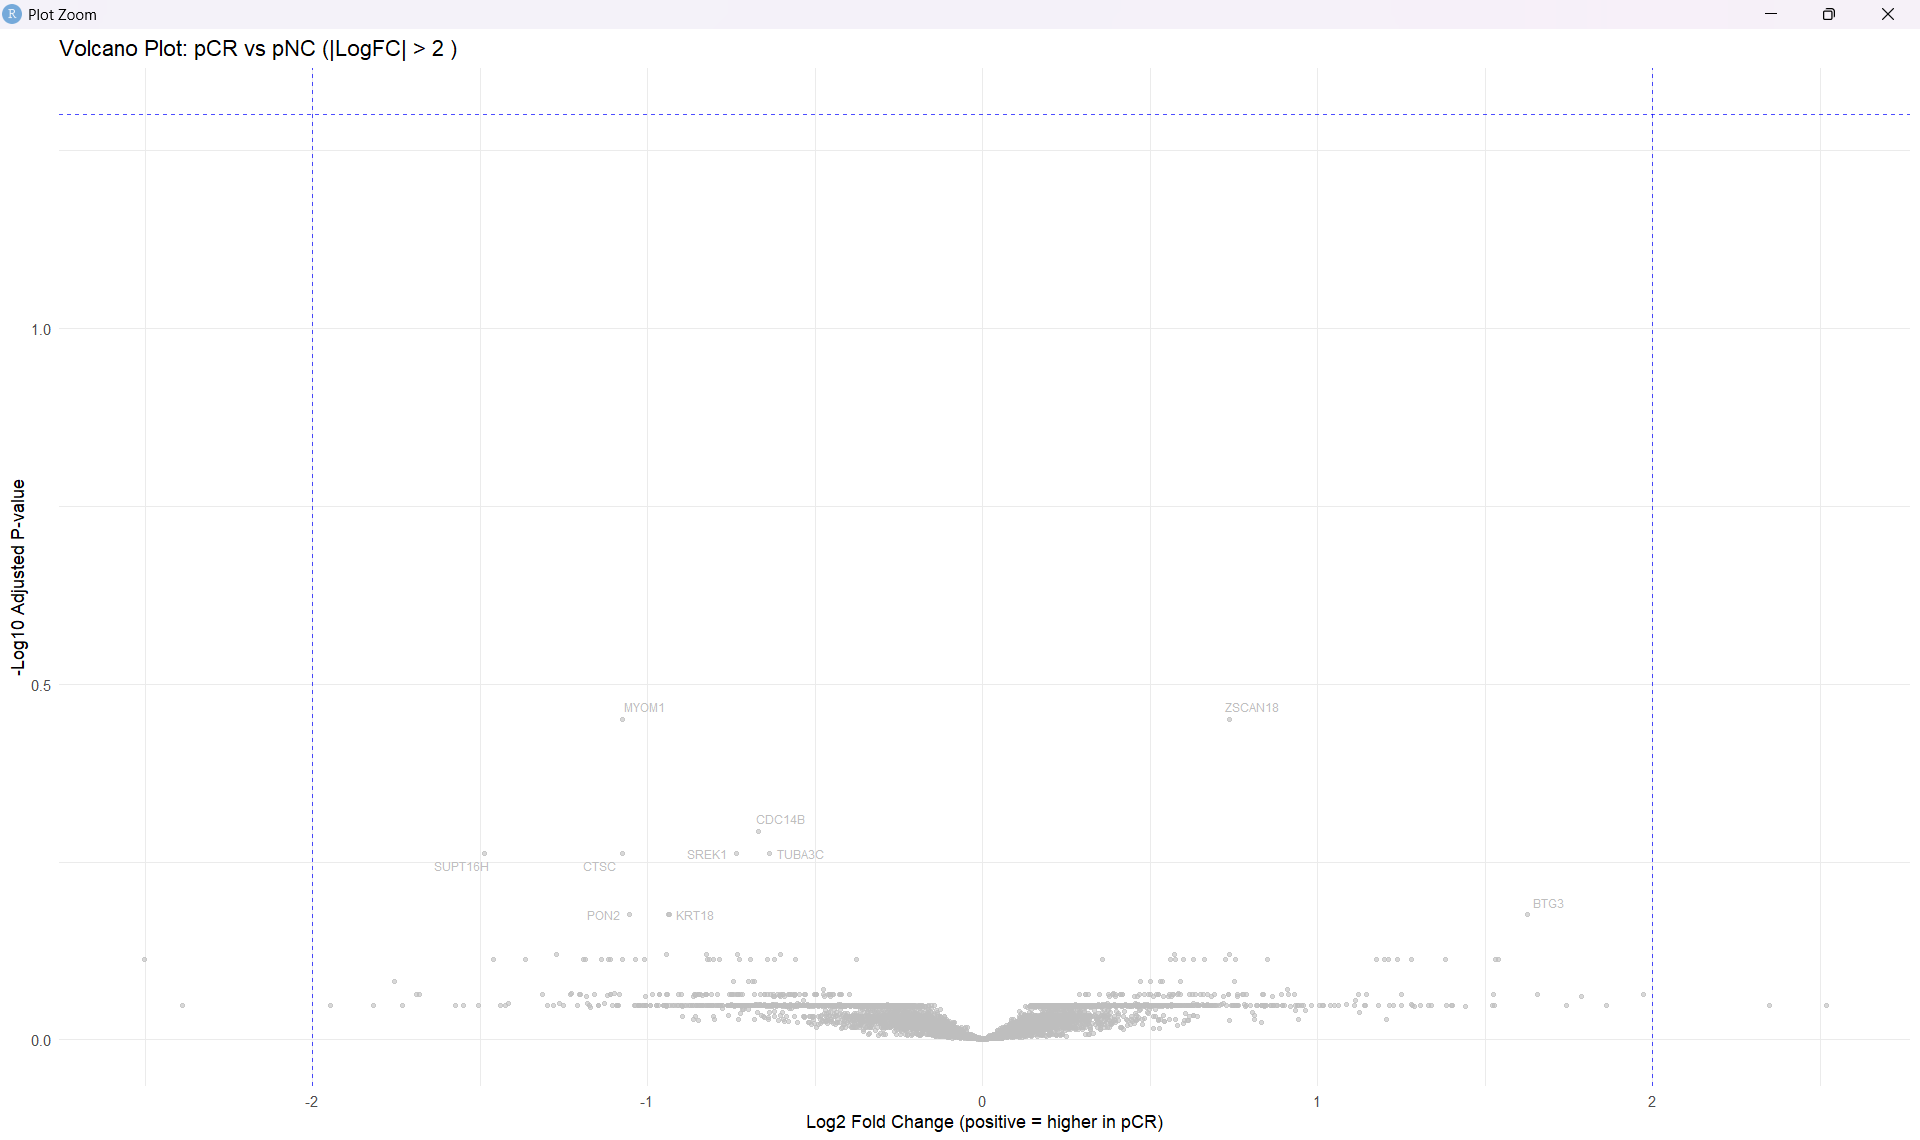

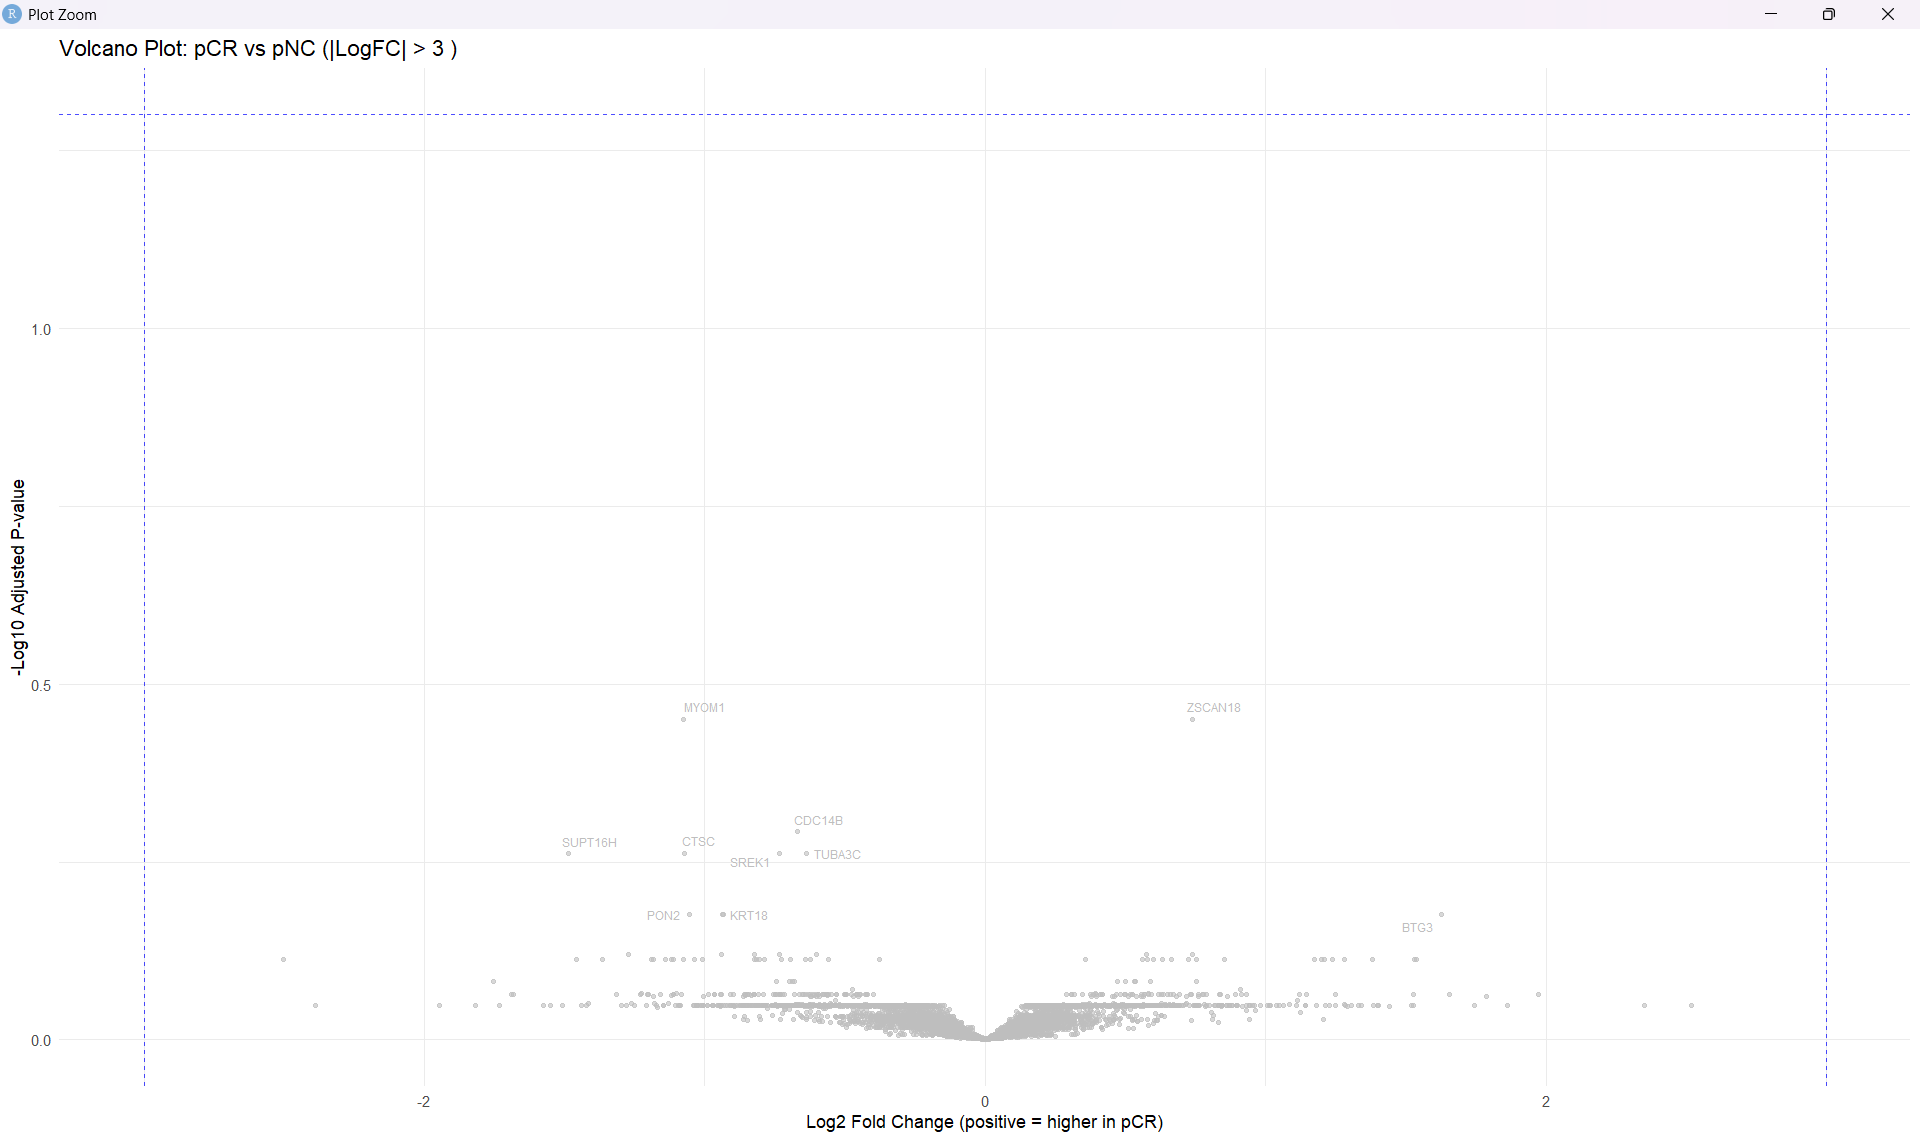

На всех трех графиках отсутствуют красные точки (значимые гены), что согласуется с табличными результатами. Большинство генов сконцентрировано вокруг logFC = 0, что указывает на отсутствие сильных различий между группами. Из-за этого невозможно выбрать лучший порог (1, 2 или 3).

#### Выводы:

В данной части работы был проведен анализ дифференциальной экспрессии между пациентами с полным и неполным ответом на химиотерапию (GSE63885) с использованием пакета LIMMA. Несмотря на отсутствие статистически значимых генов после коррекции, анализ p-value выявил наличие слабых сигналов. Скорее всего для решения данной задачи стоит использовать более чувствительные методы.